# **Temperature Plotter**

In [ ]:
# Step 1: Load Data

import pandas as pd
import matplotlib.pyplot as plt

def load_data(file_path):
    """Load temperature data from a CSV file."""
    try:
        data = pd.read_csv(file_path, parse_dates=["Date"])
        print("Data loaded successfully!")
        return data
    except Exception as e:
        print("Error loading data:", e)
        return None

In [ ]:
# Step 2: Plot Temperature Data with Rolling Average and Anomalies
def plot_temperature(data, save_file=None):
    """Plot temperature trends with rolling average and anomalies."""

    # Add 7-Day Rolling Average
    data["7-Day Average"] = data["Temperature"].rolling(window=7).mean()

    # Identify Anomalies (±2 standard deviations from mean)
    mean_temp = data["Temperature"].mean()
    std_temp = data["Temperature"].std()
    data["Anomaly"] = (data["Temperature"] > mean_temp + 2 * std_temp) | (data["Temperature"] < mean_temp - 2 * std_temp)

    # Create Plot
    plt.style.use("seaborn-v0_8-whitegrid")
    plt.figure(figsize=(10, 6))
    plt.plot(data["Date"], data["Temperature"], label="Daily Temperature", color="blue")
    plt.plot(data["Date"], data["7-Day Average"], label="7-Day Average", linestyle="--", color="orange")
    plt.scatter(data[data["Anomaly"]]["Date"], data[data["Anomaly"]]["Temperature"], color="red", label="Anomalies")
    plt.title("Temperature Trends")
    plt.xlabel("Date")
    plt.ylabel("Temperature (°C)")
    plt.legend()
    plt.grid(True)

    # Save or Show Plot
    if save_file:
        plt.savefig(save_file)
        print(f"Plot saved as {save_file}")
    else:
        plt.show()

In [ ]:
# Step 3: Main Function to Run Program
def main():
    print("Welcome to the Temperature Plotter!")

    # Load Data from User Input
    file_path = input("Enter the path to your temperature CSV file: ")
    data = load_data(file_path)
    if data is None:
        return

    # Ask User if They Want to Save the Plot
    save_choice = input("Do you want to save the plot? (yes/no): ").lower()
    if save_choice == "yes":
        file_name = input("Enter the file name (e.g., temperature_plot.png): ")
        plot_temperature(data, save_file=file_name)
    else:
        plot_temperature(data)


Welcome to the Temperature Plotter!
Enter the path to your temperature CSV file: /content/temperature_data.csv
Data loaded successfully!
Do you want to save the plot? (yes/no): Yes
Enter the file name (e.g., temperature_plot.png): jpg
Plot saved as jpg


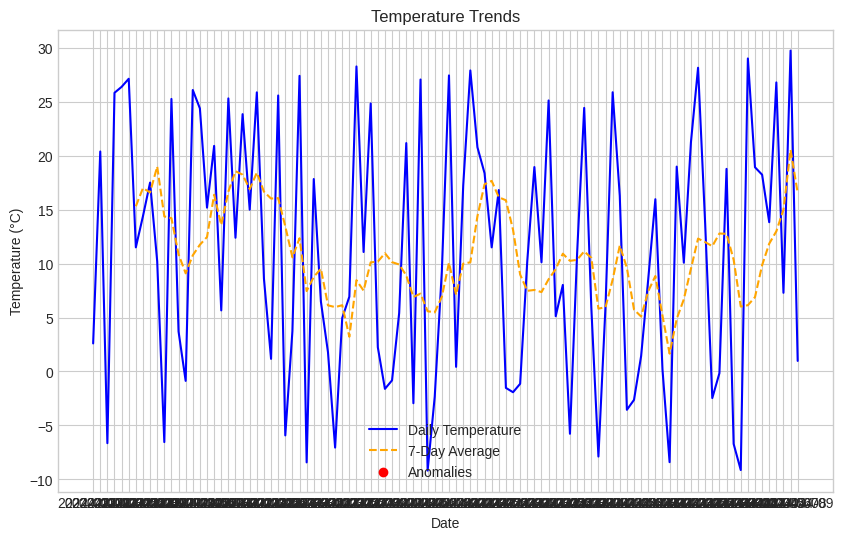

In [ ]:
# Step 4: Run Program
if __name__ == "__main__":
    main()